In [1]:
import pandas as pd

# Đọc file CSV đã được tiền xử lý
csv_path = "cleaned_order_history.csv"
df = pd.read_csv(csv_path)

# Hiển thị các cột để kiểm tra cấu trúc
df.columns


Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID'],
      dtype='object')

In [2]:
# Lọc các dòng có 'Order Market Value' là "Incorrected"
incorrected_rows = df[df['Order Ready Marked'] == "Incorrectly"]

# In ra kết quả
print(incorrected_rows)

print(f"Số dòng có Order Ready Marked là 'incorrectly': {len(incorrected_rows)}")


       Restaurant ID    Restaurant name                  Subzone       City  \
6           20320607              Swaad                 Sector 4  Delhi NCR   
18          20320607              Swaad                 Sector 4  Delhi NCR   
26          20320607              Swaad                 Sector 4  Delhi NCR   
32          20320607              Swaad                 Sector 4  Delhi NCR   
33          20320607              Swaad                 Sector 4  Delhi NCR   
...              ...                ...                      ...        ...   
21255       21143186  Tandoori Junction  Greater Kailash 2 (GK2)  Delhi NCR   
21259       21145152  Tandoori Junction                 Sector 4  Delhi NCR   
21292       21309083              Swaad               Sector 135  Delhi NCR   
21297       21309083              Swaad               Sector 135  Delhi NCR   
21318       21523055    Masala Junction                 Sector 4  Delhi NCR   

         Order ID      Order Placed At Order Status

In [3]:
from sklearn.model_selection import train_test_split

# Tách train-test theo tỉ lệ 80:20
train_df, test_df = train_test_split(incorrected_rows, test_size=0.2, random_state=42)

# In số dòng
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")


Train size: 1516, Test size: 379


In [4]:
# Chọn tập train (đã lọc incorrectly)
rider_wait_times = train_df['Rider wait time (minutes)'].dropna()

# Tính các percentile phổ biến
percentiles = [0, 10, 25, 50,70, 75, 90, 95, 99, 100]
percentile_values = rider_wait_times.quantile([p/100 for p in percentiles])

# Hiển thị kết quả
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value:.2f} phút")


0th percentile: 0.20 phút
10th percentile: 3.41 phút
25th percentile: 4.50 phút
50th percentile: 7.20 phút
70th percentile: 9.90 phút
75th percentile: 11.00 phút
90th percentile: 15.50 phút
95th percentile: 18.70 phút
99th percentile: 27.29 phút
100th percentile: 73.80 phút


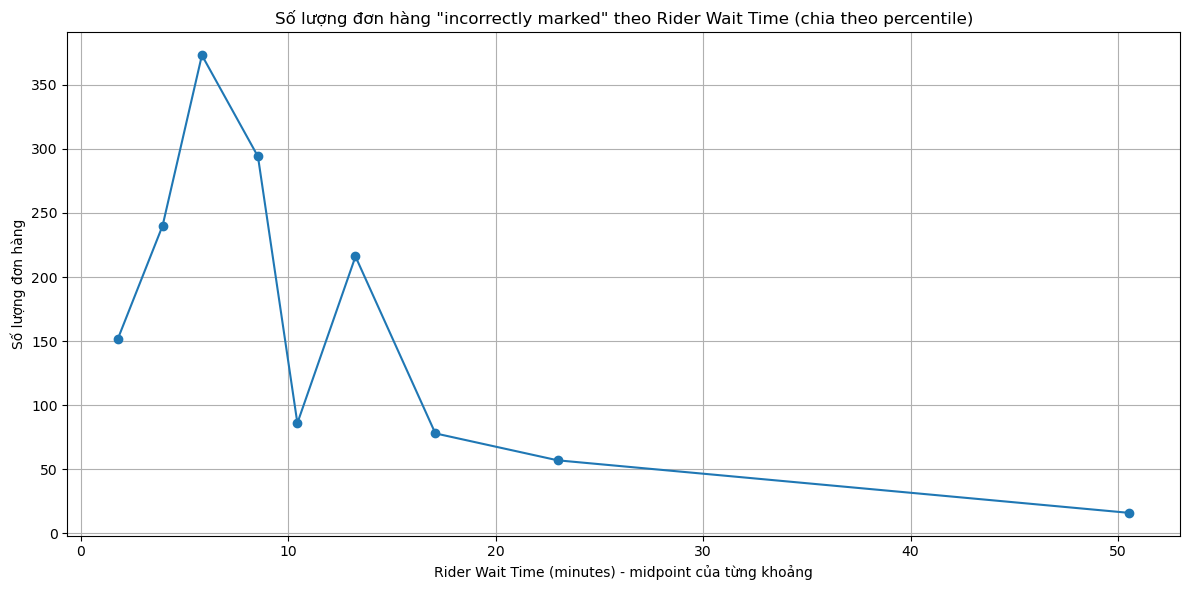

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Tạo DataFrame phân vị
custom_percentile_df = percentile_values.reset_index()
custom_percentile_df.columns = ['Percentile', 'Rider Wait Time (minutes)']

# Loại trùng và đảm bảo bins tăng dần
bins = sorted(set(custom_percentile_df['Rider Wait Time (minutes)'].tolist()))

# Tạo labels cho mỗi khoảng
labels = [f"{percentiles[i]}-{percentiles[i+1]}%" for i in range(len(bins) - 1)]

# Cắt dữ liệu thành nhóm
train_df['Wait Time Group'] = pd.cut(
    train_df['Rider wait time (minutes)'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Đếm số lượng đơn hàng trong từng nhóm
group_counts = train_df['Wait Time Group'].value_counts().sort_index()

# Tính midpoint của từng khoảng (trục X)
mid_points = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]

# Vẽ biểu đồ line
plt.figure(figsize=(12, 6))
plt.plot(mid_points, group_counts.values, marker='o')
plt.title('Số lượng đơn hàng "incorrectly marked" theo Rider Wait Time (chia theo percentile)')
plt.xlabel('Rider Wait Time (minutes) - midpoint của từng khoảng')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.tight_layout()
plt.show()



0th percentile: 0.20 phút
10th percentile: 3.40 phút
25th percentile: 4.50 phút
50th percentile: 7.20 phút
70th percentile: 10.10 phút
85th percentile: 13.56 phút
90th percentile: 15.50 phút
95th percentile: 18.70 phút
99th percentile: 26.54 phút
100th percentile: 73.80 phút


C:\Users\krizb\AppData\Local\Temp\ipykernel_2664\2258542518.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incorrect_ready['Wait Time Group'] = pd.cut(


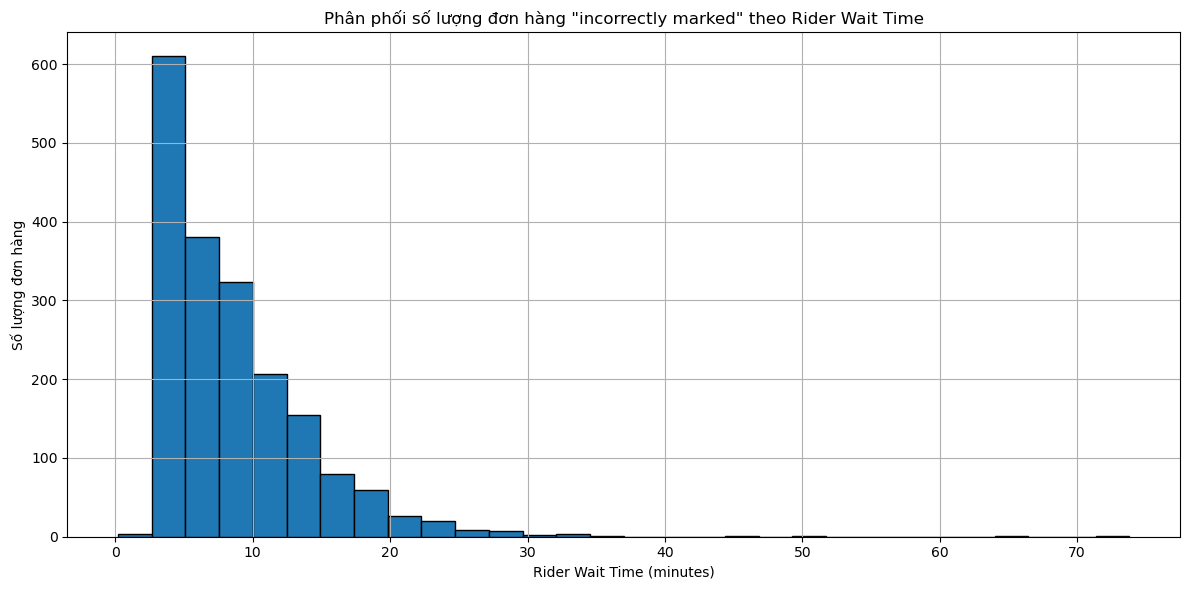

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Không dùng train-test, dùng toàn bộ dữ liệu có Order Ready Marked = 'incorrectly'
df_incorrect_ready = df[df['Order Ready Marked'].str.lower() == 'incorrectly']

# Tính phân vị rider wait time
rider_wait_times = df_incorrect_ready['Rider wait time (minutes)'].dropna()
percentiles = [0, 10, 25, 50, 70 ,85, 90, 95, 99, 100]
percentile_values = rider_wait_times.quantile([p/100 for p in percentiles])

# Hiển thị kết quả
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value:.2f} phút")

# Tạo DataFrame chứa phân vị
custom_percentile_df = percentile_values.reset_index()
custom_percentile_df.columns = ['Percentile', 'Rider Wait Time (minutes)']

# Loại trùng và đảm bảo tăng dần
bins = sorted(set(custom_percentile_df['Rider Wait Time (minutes)'].tolist()))

# Tạo labels tương ứng với số khoảng (bins - 1)
labels = [f"{percentiles[i]}-{percentiles[i+1]}%" for i in range(len(bins) - 1)]

# Cắt dữ liệu thành nhóm
df_incorrect_ready['Wait Time Group'] = pd.cut(
    df_incorrect_ready['Rider wait time (minutes)'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Đếm số lượng đơn hàng theo từng nhóm
group_counts = df_incorrect_ready['Wait Time Group'].value_counts().sort_index()

# Tính midpoint các khoảng để vẽ biểu đồ
mid_points = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]

# Vẽ biểu đồ phân bố dạng histogram theo Rider wait time
plt.figure(figsize=(12, 6))
plt.hist(incorrected_rows['Rider wait time (minutes)'].dropna(), bins=30, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.tight_layout()
plt.show()


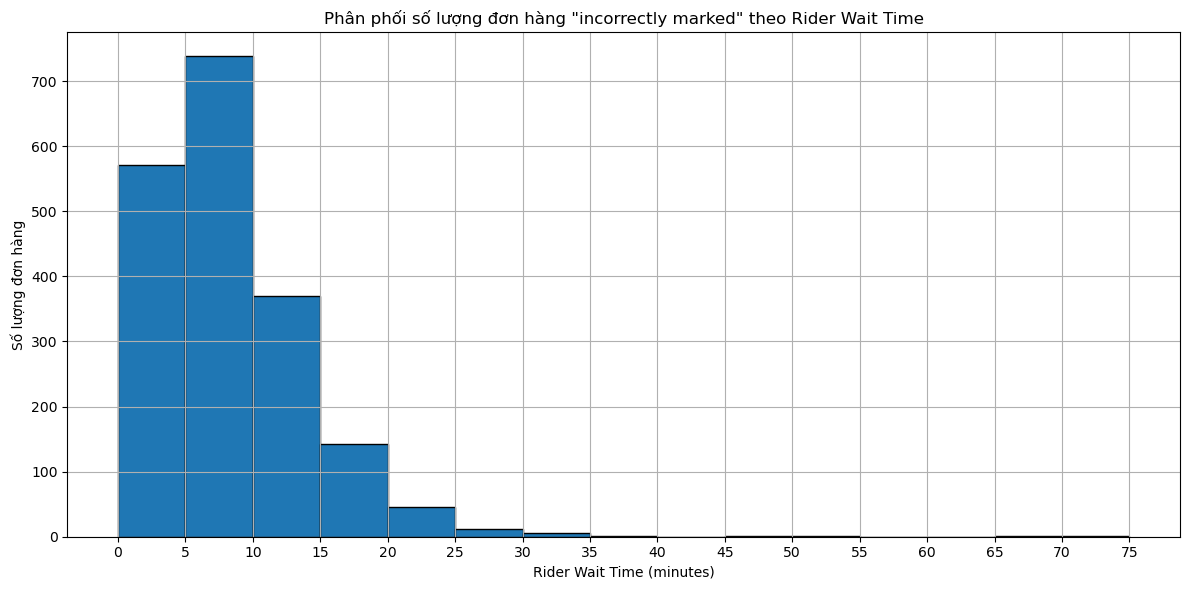

In [8]:
import numpy as np

# Tạo bins mỗi 5 phút
max_time = int(rider_wait_times.max()) + 5
bins = np.arange(0, max_time + 1, 5)  # ví dụ: 0, 5, 10, ..., max

# Vẽ histogram
plt.figure(figsize=(12, 6))
plt.hist(rider_wait_times, bins=bins, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(bins)  # Set nhãn trục x đúng mỗi 5 phút
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# Lấy giá trị mode từ biến đã có
mode_value = mode_rider_wait.iloc[0]

# Tính tổng số lần giá trị mode đó xuất hiện
mode_count = (df_incorrect_ready['Rider wait time (minutes)'] == mode_value).sum()

mode_value, mode_count


NameError: name 'mode_rider_wait' is not defined